In [144]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

sns.set_style("whitegrid")

### Tâche 1 : Chargement et Exploration
- Chargez le dataset de régression
- Explorez les features et la target
- Analysez les distributions, correlations
- Identifiez les outliers

In [81]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
)

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [83]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


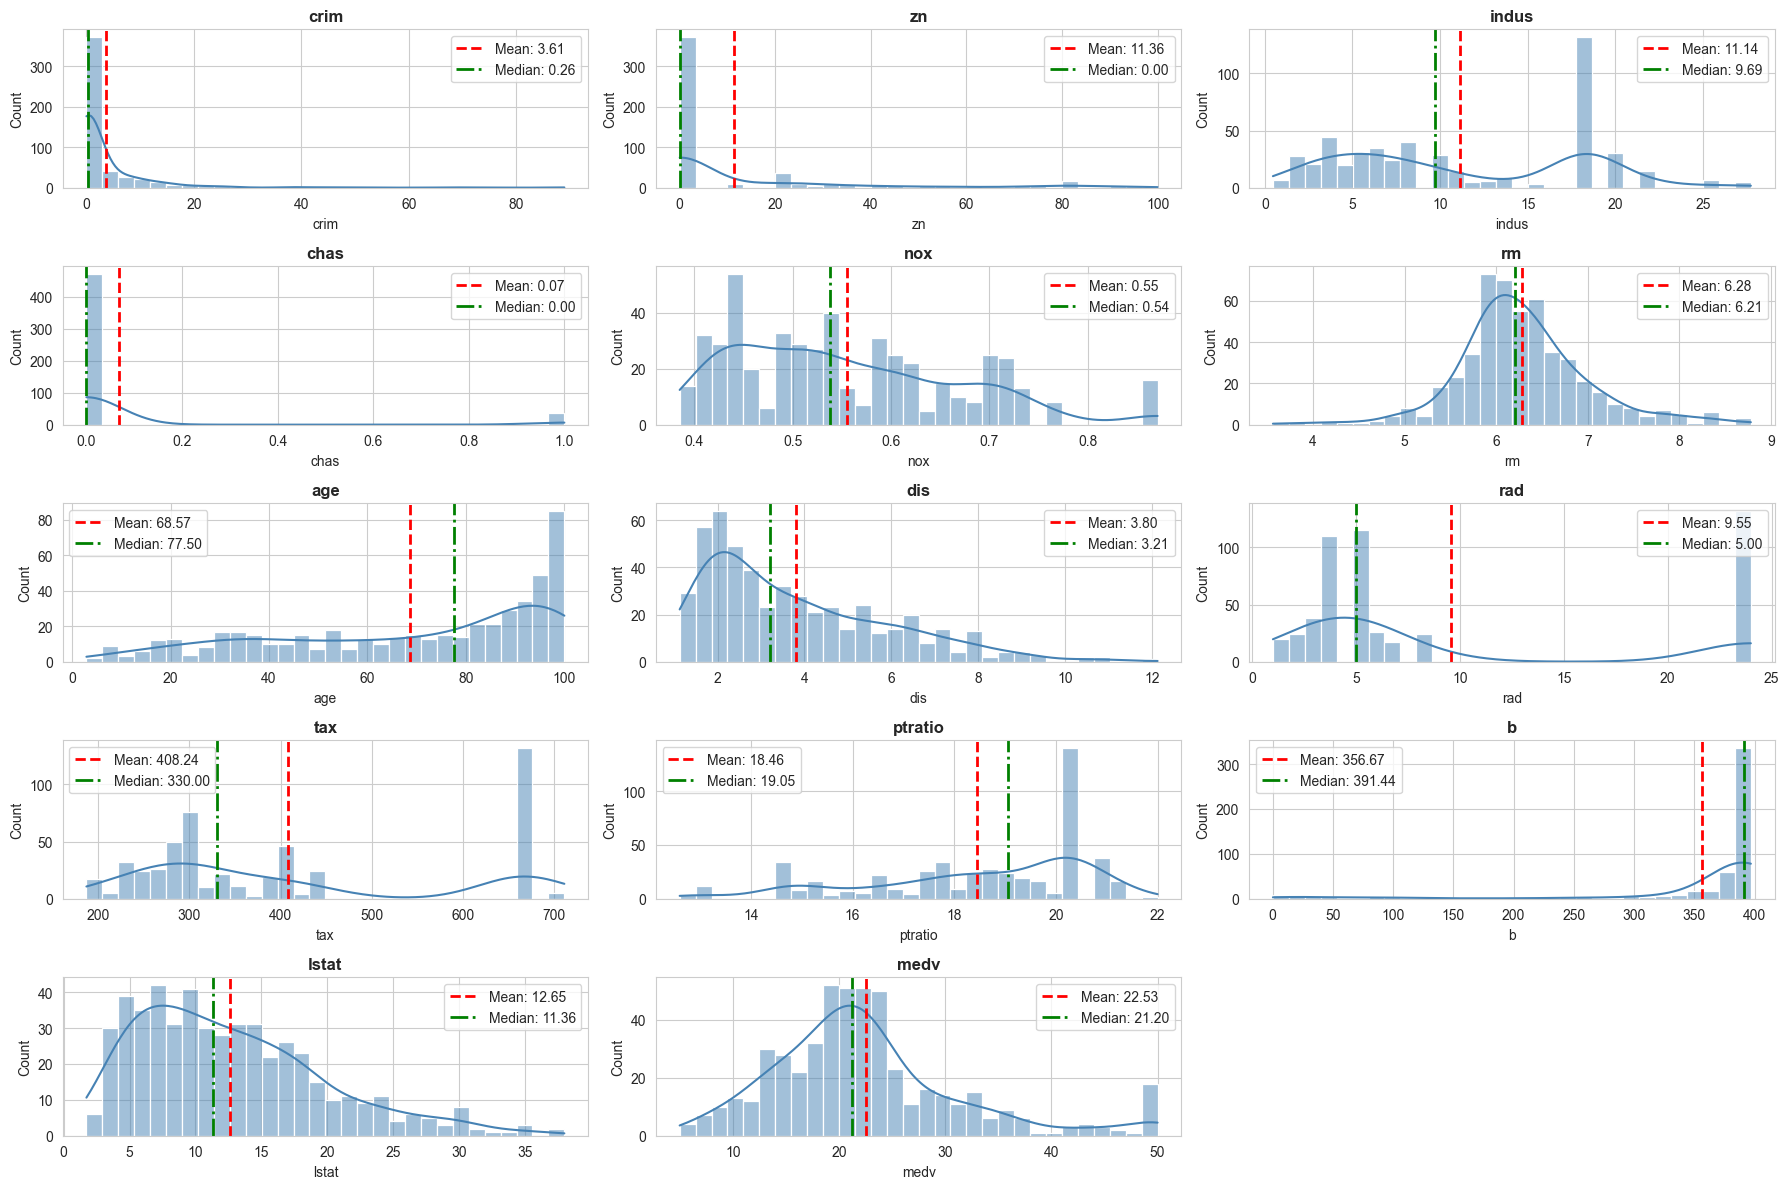

In [84]:
n_cols = 3
n_rows = int(len(df.columns) / n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue", bins=30)

    mean = df[col].mean()
    median = df[col].median()

    ax.axvline(
        mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean:.2f}"
    )
    ax.axvline(
        median,
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Median: {median:.2f}",
    )

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

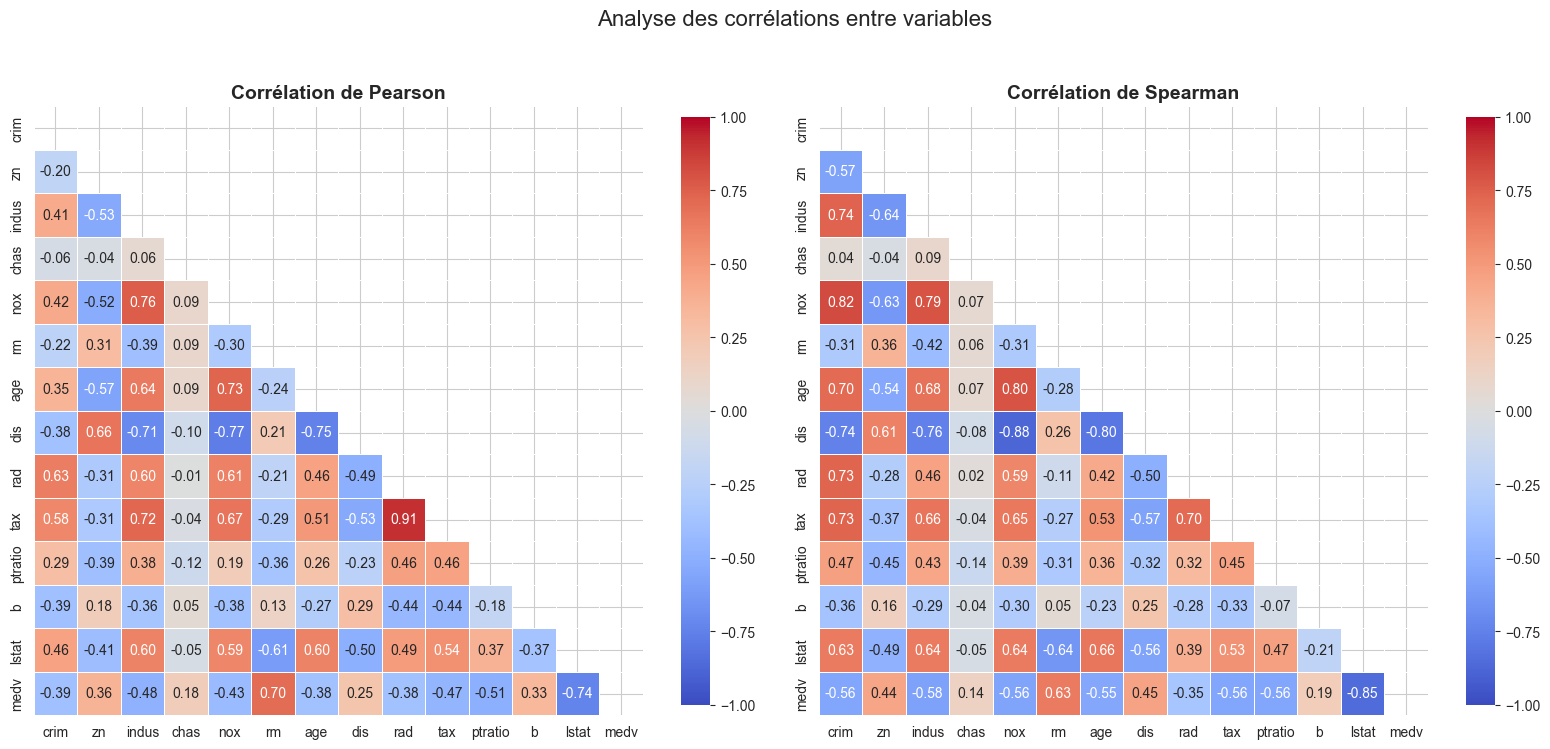

In [85]:
df_corr_pearson = df.corr(method="pearson")
df_corr_spearman = df.corr(method="spearman")

mask = np.triu(np.ones_like(df_corr_pearson, dtype=bool))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

sns.heatmap(
    df_corr_pearson,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax1,
)

ax1.set_title("Corrélation de Pearson", fontsize=14, fontweight="bold")

sns.heatmap(
    df_corr_spearman,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax2,
)

ax2.set_title("Corrélation de Spearman", fontsize=14, fontweight="bold")

fig.suptitle("Analyse des corrélations entre variables", fontsize=16)

plt.tight_layout()
plt.show()

In [86]:
def analyze_correlations(df_corr_pearson, df_corr_spearman, diff_threshold=0.1):

    results = []
    cols = df_corr_pearson.columns

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            var1 = cols[i]
            var2 = cols[j]

            pearson = df_corr_pearson.loc[var1, var2]
            spearman = df_corr_spearman.loc[var1, var2]

            abs_p = abs(pearson)
            abs_s = abs(spearman)

            max_corr = max(abs_p, abs_s)

            if max_corr < 0.2:
                strength = "très faible"
            elif max_corr < 0.4:
                strength = "faible"
            elif max_corr < 0.6:
                strength = "modérée"
            elif max_corr < 0.8:
                strength = "forte"
            else:
                strength = "très forte"

            diff = abs(abs_p - abs_s)

            if diff < diff_threshold:
                relation = "relation probablement linéaire"

            elif abs_s > abs_p:
                relation = "relation monotone probablement non linéaire"

            else:
                relation = "possible influence d'outliers"

            results.append(
                {
                    "var1": var1,
                    "var2": var2,
                    "pearson": pearson,
                    "spearman": spearman,
                    "force_corr": strength,
                    "diagnostic": relation,
                }
            )

    return pd.DataFrame(results)


df_corr_analysis = analyze_correlations(df_corr_pearson, df_corr_spearman)
df_corr_analysis.sort_values(by="pearson", key=abs, ascending=False).head(10)

,var1,var2,pearson,spearman,force_corr,diagnostic
76,rad,tax,0.910228,0.704876,très forte,possible influence d'outliers
48,nox,dis,-0.769230,-0.880015,très forte,relation monotone probablement non linéaire
26,indus,nox,0.763651,0.791189,forte,relation probablement linéaire
63,age,dis,-0.747881,-0.801610,très forte,relation probablement linéaire
90,lstat,medv,-0.737663,-0.852914,très forte,relation monotone probablement non linéaire
47,nox,age,0.731470,0.795153,forte,relation probablement linéaire
31,indus,tax,0.720760,0.664361,forte,relation probablement linéaire
29,indus,dis,-0.708027,-0.757080,forte,relation probablement linéaire
62,rm,medv,0.695360,0.633576,forte,relation probablement linéaire
50,nox,tax,0.668023,0.649527,forte,relation probablement linéaire


In [87]:
df_corr_analysis[df_corr_analysis["var2"] == "medv"].sort_values(
    by="pearson", key=abs, ascending=False
).head(20)

,var1,var2,pearson,spearman,force_corr,diagnostic
90,lstat,medv,-0.737663,-0.852914,très forte,relation monotone probablement non linéaire
62,rm,medv,0.695360,0.633576,forte,relation probablement linéaire
87,ptratio,medv,-0.507787,-0.555905,modérée,relation probablement linéaire
35,indus,medv,-0.483725,-0.578255,modérée,relation probablement linéaire
84,tax,medv,-0.468536,-0.562411,modérée,relation probablement linéaire
54,nox,medv,-0.427321,-0.562609,modérée,relation monotone probablement non linéaire
12,crim,medv,-0.388305,-0.558891,modérée,relation monotone probablement non linéaire
80,rad,medv,-0.381626,-0.346776,faible,relation probablement linéaire
69,age,medv,-0.376955,-0.547562,modérée,relation monotone probablement non linéaire
24,zn,medv,0.360445,0.438179,modérée,relation probablement linéaire


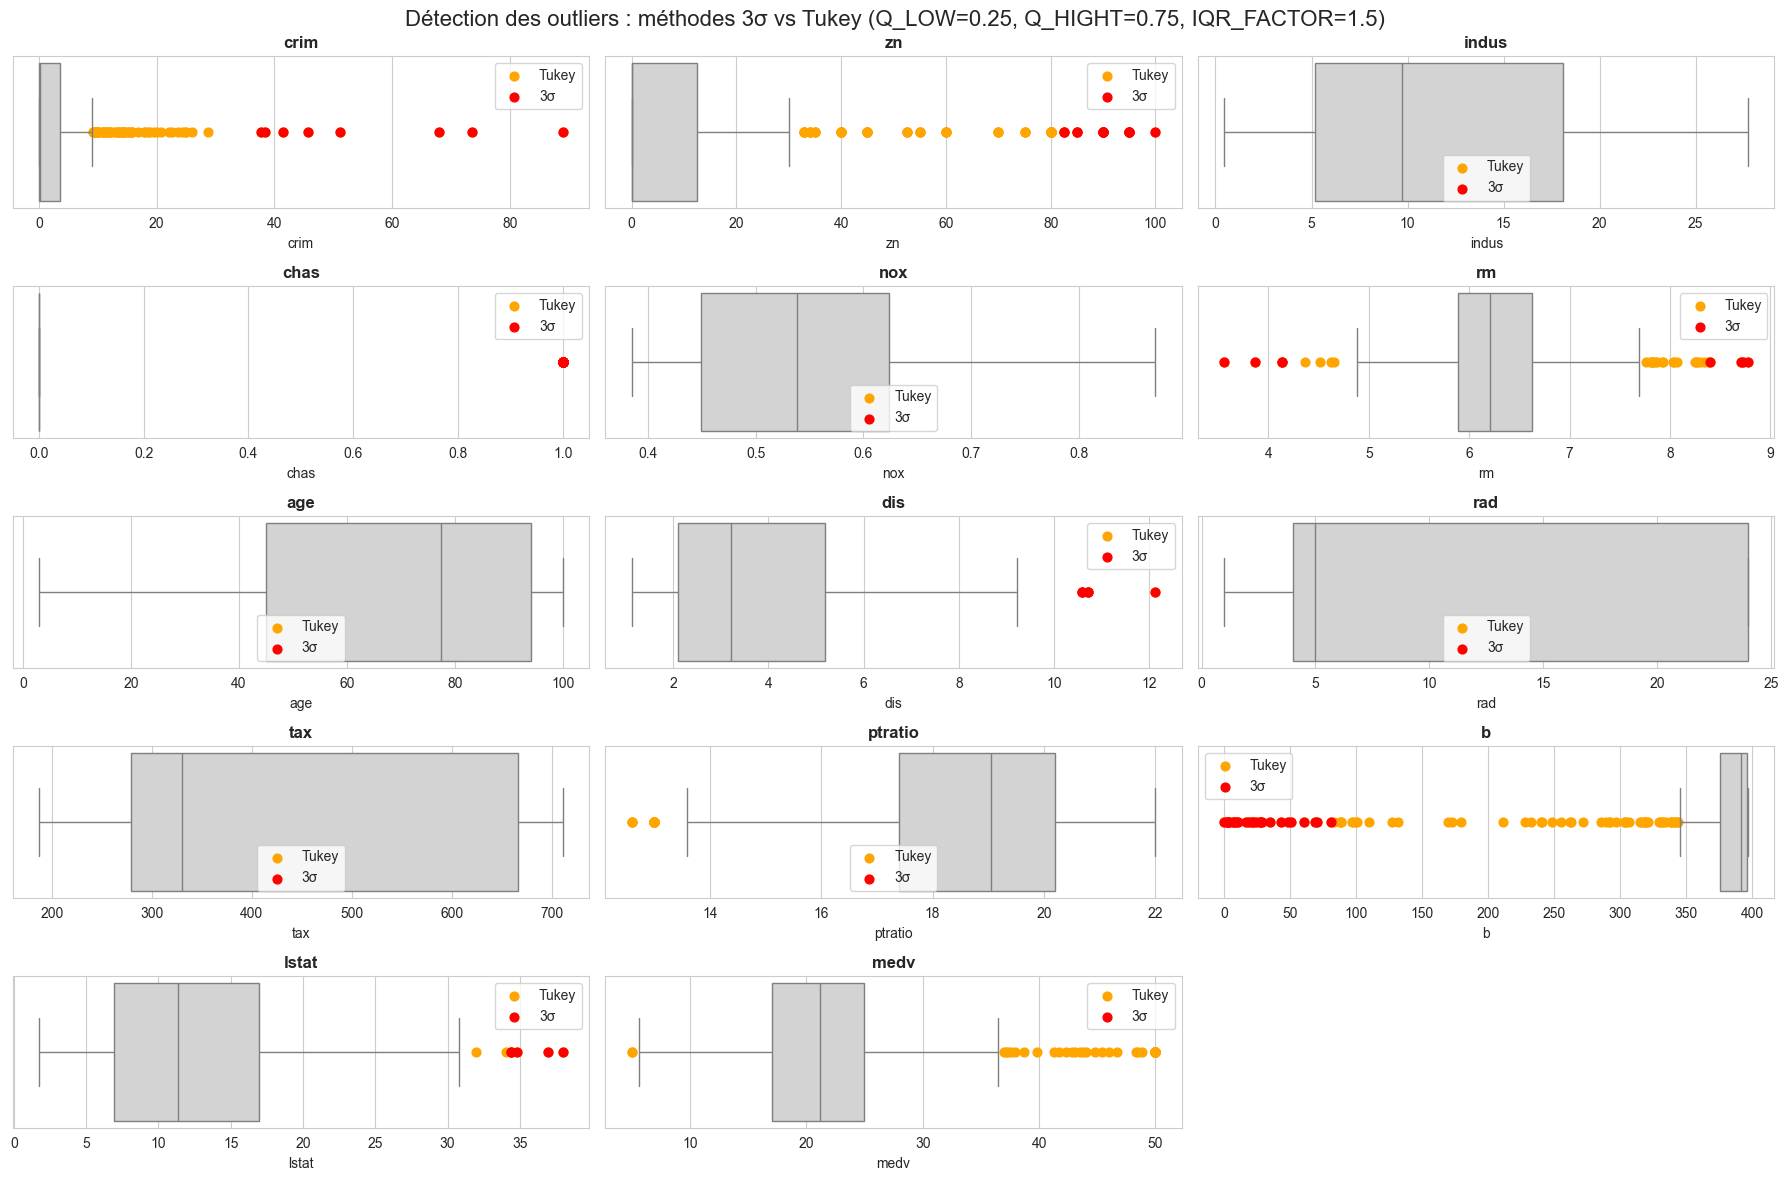

In [88]:
Q_LOW = 0.25
Q_HIGH = 0.75
IQR_FACTOR = 1.5

n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    ax = axes[i]
    data = df[col]

    sns.boxplot(x=data, ax=ax, color="lightgray", showfliers=False)

    q1 = data.quantile(Q_LOW)
    q3 = data.quantile(Q_HIGH)

    iqr = q3 - q1

    lower_bound = q1 - IQR_FACTOR * iqr
    upper_bound = q3 + IQR_FACTOR * iqr

    mask_tukey = (data < lower_bound) | (data > upper_bound)
    outliers_tukey = data[mask_tukey]

    ax.scatter(
        outliers_tukey,
        np.zeros_like(outliers_tukey),
        color="orange",
        s=40,
        label="Tukey",
    )

    mean = data.mean()
    std = data.std()

    mask_3sigma = (data > mean + 3 * std) | (data < mean - 3 * std)
    outliers_3sigma = data[mask_3sigma]

    ax.scatter(
        outliers_3sigma, np.zeros_like(outliers_3sigma), color="red", s=40, label="3σ"
    )

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    f"Détection des outliers : méthodes 3σ vs Tukey (Q_LOW={Q_LOW}, Q_HIGHT={Q_HIGH}, IQR_FACTOR={IQR_FACTOR})",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [89]:
def outliers_analysis(df, q_low=0.25, q_high=0.75, iqr_factor=1.5):
    results = []

    for col in df.columns:
        data = df[col].dropna()

        q1 = data.quantile(q_low)
        q3 = data.quantile(q_high)
        iqr = q3 - q1
        lower_bound_tukey = q1 - iqr_factor * iqr
        upper_bound_tukey = q3 + iqr_factor * iqr

        mask_tukey = (data < lower_bound_tukey) | (data > upper_bound_tukey)
        n_tukey = mask_tukey.sum()
        pct_tukey = n_tukey / len(data) * 100

        mean = data.mean()
        std = data.std()
        mask_3sigma = (data < mean - 3 * std) | (data > mean + 3 * std)
        n_3sigma = mask_3sigma.sum()
        pct_3sigma = n_3sigma / len(data) * 100

        results.append(
            {
                "variable": col,
                "n_outliers_tukey": n_tukey,
                "pct_outliers_tukey": pct_tukey,
                "n_outliers_3sigma": n_3sigma,
                "pct_outliers_3sigma": pct_3sigma,
            }
        )

    return pd.DataFrame(results).sort_values(by="pct_outliers_tukey", ascending=False)


df_outliers = outliers_analysis(df, q_low=Q_LOW, q_high=Q_HIGH, iqr_factor=IQR_FACTOR)
df_outliers.head(10)

,variable,n_outliers_tukey,pct_outliers_tukey,n_outliers_3sigma,pct_outliers_3sigma
11,b,77,15.217391,25,4.940711
1,zn,68,13.438735,14,2.766798
0,crim,66,13.043478,8,1.581028
13,medv,40,7.905138,0,0.000000
3,chas,35,6.916996,35,6.916996
5,rm,30,5.928854,8,1.581028
10,ptratio,15,2.964427,0,0.000000
12,lstat,7,1.383399,5,0.988142
7,dis,5,0.988142,5,0.988142
2,indus,0,0.000000,0,0.000000


### Tâche 2 : Préparation
- Normalisez les features (StandardScaler)
- Split train/val/test
- Gestion des valeurs manquantes si applicable

In [90]:
preprocessor = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

In [103]:
X = df.drop("medv", axis=1)
y = df["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


In [92]:
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

### Tâche 3 : Architecture MLP
- Construisez un MLP pour régression :
  - 3-4 couches hidden
  - Activation ReLU
  - Output : 1 unité, activation linéaire (pas sigmoid!)
- Loss : MSE ou MAE
- Optimizer : Adam

In [93]:
OPTIMIZER = "adam"
LOSS = "mse"
METRIC = "mae"


def create_model():
    model = keras.Sequential(
        [
            layers.Input(shape=(X.shape[1],), name="input"),
            layers.Dense(64, activation="relu", name="hidden1"),
            layers.Dense(32, activation="relu", name="hidden2"),
            layers.Dense(16, activation="relu", name="hidden3"),
            layers.Dense(1, activation="linear", name="output"),
        ]
    )

    model.compile(
        optimizer=OPTIMIZER,
        loss=LOSS,
        metrics=[METRIC],
    )
    return model


model = create_model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

### Tâche 4 : Entraînement
- Entraînez 100 epochs
- Visualisez train/val loss
- Évaluez sur test set (MSE, RMSE, MAE, R²)

In [95]:
def create_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )


def create_reduce_lr():
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train_scaled,
    y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.2,
    callbacks=[create_reduce_lr(), create_early_stopping()],
    verbose=1,
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 592.2368 - mae: 22.4675 - val_loss: 527.8485 - val_mae: 21.4871 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 576.1285 - mae: 22.1395 - val_loss: 511.3044 - val_mae: 21.1305 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 556.4365 - mae: 21.7336 - val_loss: 491.1098 - val_mae: 20.6877 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 531.7079 - mae: 21.2158 - val_loss: 466.0762 - val_mae: 20.1276 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 500.9559 - mae: 20.5540 - val_loss: 435.4103 - val_mae: 19.4161 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 462.9673 - mae: 19.7033 - val_loss: 397.3692 - val_mae: 18.4911 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 416.0192 - mae: 18.5915 - val_loss: 350.5698 - val_mae: 17.2752 - learn

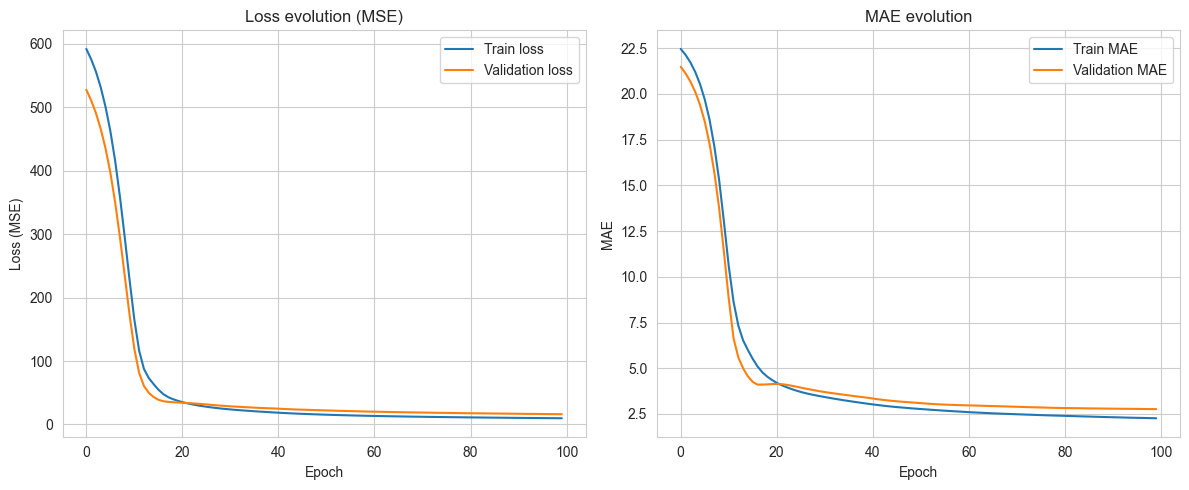

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel(f"Loss ({LOSS.upper()})")
ax1.set_title(f"Loss evolution ({LOSS.upper()})")
ax1.legend()

# Metric
ax2.plot(history.history[METRIC], label=f"Train {METRIC.upper()}")
ax2.plot(history.history[f"val_{METRIC}"], label=f"Validation {METRIC.upper()}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel(f"{METRIC.upper()}")
ax2.set_title(f"{METRIC.upper()} evolution")
ax2.legend()

plt.tight_layout()
plt.show()

In [104]:
y_pred = model.predict(X_test_scaled)
print("y_pred shape:", y_pred.shape)

print("\nMetrics:")
print("  MAE: ", mean_absolute_error(y_test, y_pred))
print("  RMSE:", root_mean_squared_error(y_test, y_pred))
print("  MSE: ", mean_squared_error(y_test, y_pred))
print("  R2:  ", r2_score(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
y_pred shape: (102, 1)

Metrics:
  MAE:  2.5124080012826364
  RMSE: 3.6754043534137004
  MSE:  13.50859716109238
  R2:   0.8157929868208249


### Tâche 5 : Analyse des Prédictions
- Comparez prédictions vs vraies valeurs
- Visualisez residuals (prédiction - réel)
- Analysez l'erreur par plage de prix
- Identifiez les prédictions les plus mauvaises

In [ ]:
df_pred_analysis = pd.DataFrame(
    {
        "medv": y_test.to_list(),
        "medv_pred": y_pred.flatten(),
    }
)
df_pred_analysis["residual"] = df_pred_analysis["medv_pred"] - df_pred_analysis["medv"]

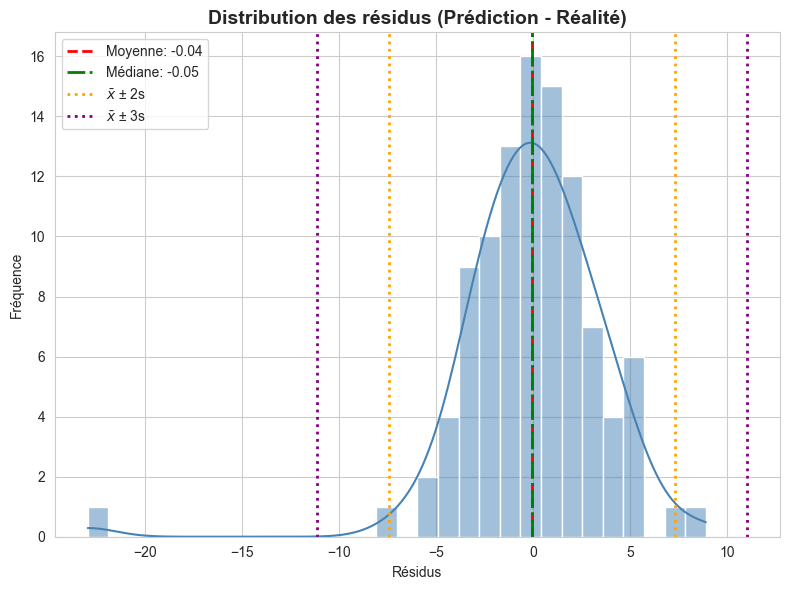

In [128]:
residuals = df_pred_analysis["residual"]
mean = residuals.mean()
std = residuals.std(ddof=1)
median = residuals.median()

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color="steelblue", bins=30)

plt.axvline(
    mean, color="red", linestyle="--", linewidth=2, label=f"Moyenne: {mean:.2f}"
)
plt.axvline(
    median, color="green", linestyle="-.", linewidth=2, label=f"Médiane: {median:.2f}"
)

plt.axvline(
    mean + 2 * std, color="orange", linestyle=":", linewidth=2, label=r"$\bar{x}$ ± 2s"
)
plt.axvline(mean - 2 * std, color="orange", linestyle=":", linewidth=2)
plt.axvline(
    mean + 3 * std, color="purple", linestyle=":", linewidth=2, label=r"$\bar{x}$ ± 3s"
)
plt.axvline(mean - 3 * std, color="purple", linestyle=":", linewidth=2)

plt.title(
    "Distribution des résidus (Prédiction - Réalité)", fontsize=14, fontweight="bold"
)
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.show()

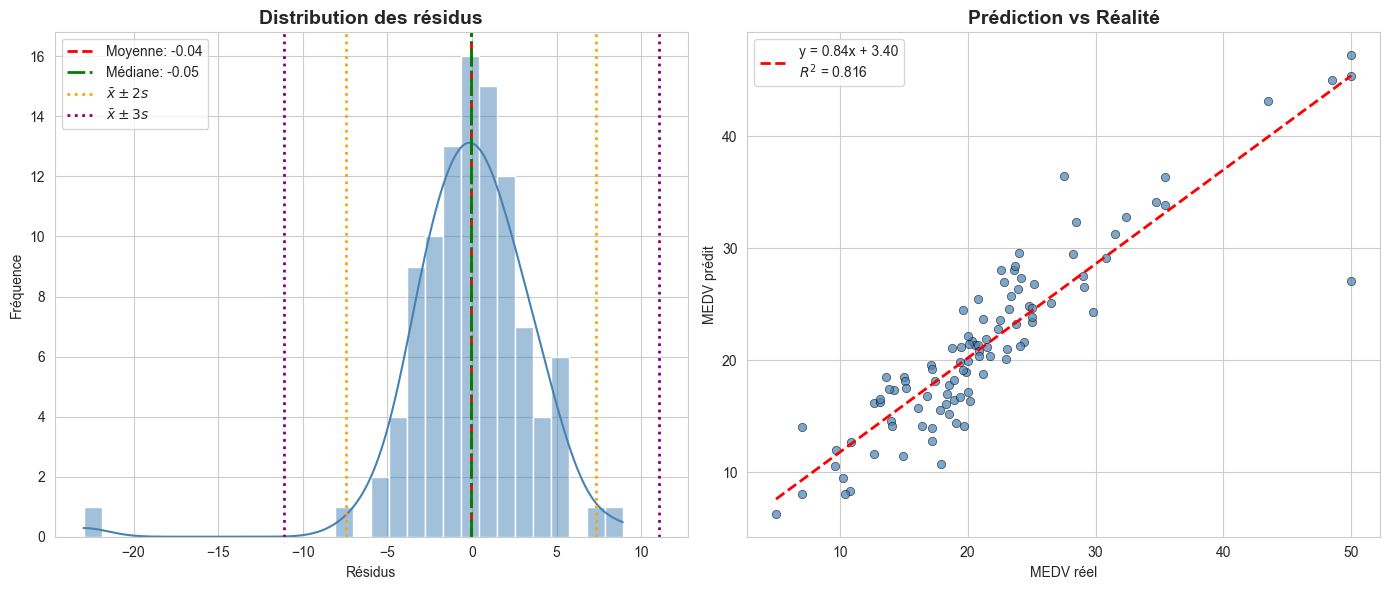

In [150]:
residuals = df_pred_analysis["residual"]
mean = residuals.mean()
std = residuals.std(ddof=1)
median = residuals.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(residuals, kde=True, color="steelblue", bins=30, ax=axes[0])

axes[0].axvline(
    mean, color="red", linestyle="--", linewidth=2, label=f"Moyenne: {mean:.2f}"
)
axes[0].axvline(
    median, color="green", linestyle="-.", linewidth=2, label=f"Médiane: {median:.2f}"
)
axes[0].axvline(
    mean + 2 * std,
    color="orange",
    linestyle=":",
    linewidth=2,
    label=r"$\bar{x} \pm 2s$",
)
axes[0].axvline(mean - 2 * std, color="orange", linestyle=":", linewidth=2)
axes[0].axvline(
    mean + 3 * std,
    color="purple",
    linestyle=":",
    linewidth=2,
    label=r"$\bar{x} \pm 3s$",
)
axes[0].axvline(mean - 3 * std, color="purple", linestyle=":", linewidth=2)

axes[0].set_title("Distribution des résidus", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Résidus")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

x = df_pred_analysis["medv"]
y = df_pred_analysis["medv_pred"]

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r2 = r_value**2

x_vals = np.linspace(x.min(), x.max(), 100)
y_vals = intercept + slope * x_vals

sns.scatterplot(x=x, y=y, ax=axes[1], color="steelblue", edgecolor="black", alpha=0.7)

axes[1].plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r2:.3f}",
)

axes[1].set_title("Prédiction vs Réalité", fontsize=14, fontweight="bold")
axes[1].set_xlabel("MEDV réel")
axes[1].set_ylabel("MEDV prédit")
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
bins = [0, 10, 20, 30, 40, np.inf]
labels = ["E", "D", "C", "B", "A"]
df_pred_analysis["medv_segment"] = pd.cut(
    df_pred_analysis["medv"], bins=bins, labels=labels, include_lowest=True
)

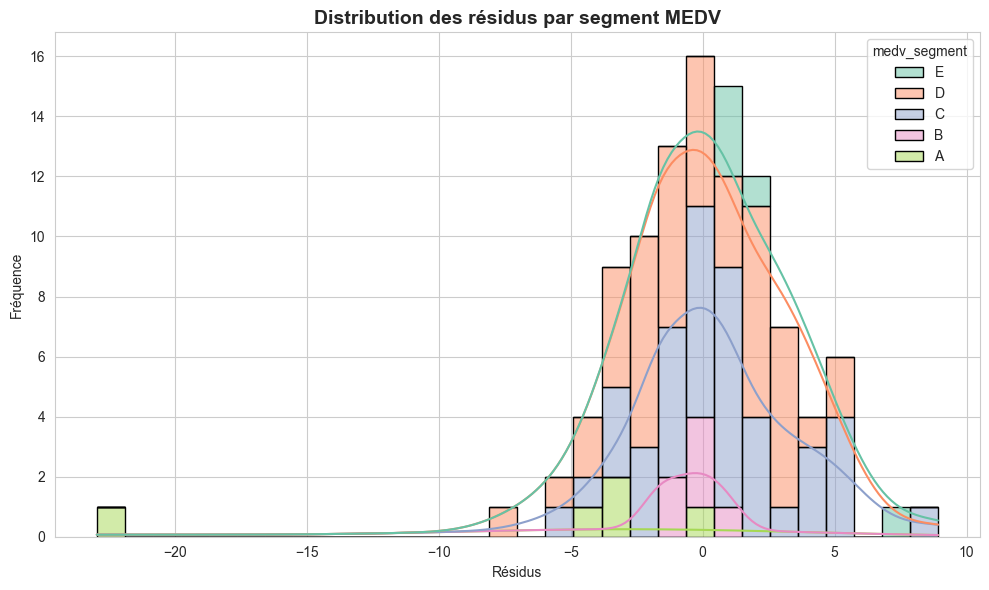

In [143]:
plt.figure(figsize=(10, 6))
sns.histplot(
    df_pred_analysis,
    x="residual",
    hue="medv_segment",
    legend=True,
    bins=30,
    kde=True,
    palette="Set2",
    multiple="stack",
    edgecolor="black",
)

plt.title("Distribution des résidus par segment MEDV", fontsize=14, fontweight="bold")
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

In [140]:
df_pred_analysis.sort_values("residual", key=abs, ascending=False).head(10)

,medv,medv_pred,residual,medv_segment
96,50.0,27.045036,-22.954964,A
94,27.5,36.413307,8.913307,C
97,17.9,10.714773,-7.185227,D
79,7.0,14.039252,7.039252,E
40,19.7,14.121378,-5.578622,D
49,24.0,29.556482,5.556482,C
15,29.8,24.281729,-5.518271,C
44,22.6,28.012583,5.412583,C
2,13.6,18.515430,4.915430,D
8,19.6,24.469013,4.869013,D


### Tâche 6 : Amélioration
- Testez différentes architectures
- Ajoutez régularisation (L2, dropout)
- Tuning learning rate
- Mesurez l'amélioration quantitativement